In [ ]:
#!pip install seaborn kaggle
#!pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"]=(8,5)

In [ ]:
!python -m pip install xlrd

In [ ]:
import pandas as pd

# TELCO
telco = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# CREDIT DEFAULT
credit_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
credit_default = pd.read_excel(credit_url, header=1)

# GERMAN CREDIT
german_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
german_credit = pd.read_csv(german_url, sep=' ', header=None)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [ ]:
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Preparing the data for model

- Bré Anna Kotary: Data preprocessing and feature engineering  
Responsible for cleaning the dataset, handling missing values, encoding categorical variables, and preparing the data for modeling.

- Tharun Reddy Marreddy: Model development and hyperparameter tuning  
Implemented machine learning models and performed hyperparameter tuning using GridSearchCV to optimize model performance and reduce overfitting.

- Srinija Chowdary Garapati: Evaluation metrics and visualization  
Calculated evaluation metrics (accuracy, precision, recall), generated confusion matrices and ROC curves, and interpreted model performance.

- Akshaya Paila: Model validation and results interpretation  
Conducted cross-validation and train/test evaluation to ensure model generalization on unseen data. Interpreted results, analyzed false positive vs. false negative tradeoffs, and provided insights on model reliability and business implications.

In [ ]:
# Delete customerID column which is not useful for prediction
telco = telco.drop("customerID", axis=1)
telco.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Convert target column to numeric
telco["Churn"] = telco["Churn"].map({"Yes":1, "No":0})
telco.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
#  Convert totalcharges to numeric
telco["TotalCharges"] = pd.to_numeric(telco["TotalCharges"], errors="coerce")
telco = telco.dropna()
telco.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
# Convert categorical columns into numeric data using one-hot encoding
telco = pd.get_dummies(telco, drop_first=True)

In [ ]:
print(telco.dtypes)

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes     

In [ ]:
# Separating the input features and target variable
X = telco.drop("Churn", axis=1)   # X is input features
y = telco["Churn"]                # y is target variable

from sklearn.model_selection import train_test_split

# Spliting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train dataset and 20% test dataset
    random_state=42,      # always take same random data
    stratify=y           # maintains class balance
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (5625, 30)
Testing data shape: (1407, 30)


### Interpretation

The dataset was split into training (5625 rows) and testing (1407 rows) sets. This ensures that the model is trained on one portion of data and evaluated on unseen data.

### Insights

The use of stratified sampling ensures that the proportion of churn and non-churn customers is maintained in both sets, which improves model reliability.

### Implication

This helps ensure that the model evaluation is fair and that performance reflects real-world prediction ability.

In [ ]:
X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1413,0,65,94.55,6078.75,True,True,True,True,False,True,...,False,False,False,False,False,True,False,True,False,False
7003,0,26,35.75,1022.50,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
3355,0,68,90.20,6297.65,False,True,False,True,False,True,...,False,False,False,False,False,True,False,True,False,False
4494,0,3,84.30,235.05,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
3541,0,49,40.65,2070.75,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False


### Feature Selection

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Training the Random Forest model to estimate feature importance
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Extract important features scores
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top Important Features:\n")
print(feature_importance.head(10))

Top Important Features:

TotalCharges                      0.191435
tenure                            0.171020
MonthlyCharges                    0.168400
InternetService_Fiber optic       0.039481
PaymentMethod_Electronic check    0.037416
Contract_Two year                 0.030529
gender_Male                       0.029332
OnlineSecurity_Yes                0.028157
PaperlessBilling_Yes              0.025536
TechSupport_Yes                   0.024114
dtype: float64


### Important features visualization

### Interpretation

The most important features influencing churn are TotalCharges, tenure, and MonthlyCharges.

### Insights

Customers with higher total charges and longer tenure show strong patterns related to churn behavior. Service-related features like InternetService and payment methods also contribute.

### Implication

These features are critical for predicting churn and should be prioritized in model building and business decision-making.

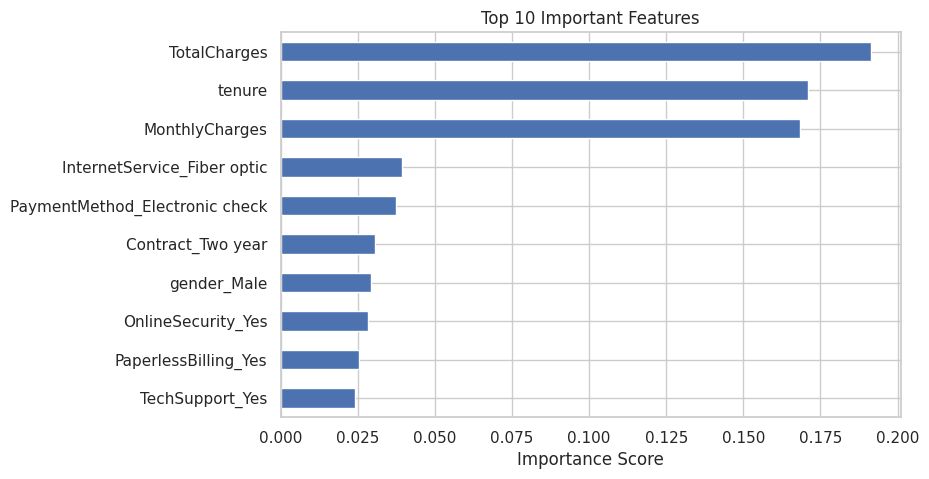

In [ ]:
feature_importance.head(10).sort_values(ascending=True).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

### Applying Feature Scaling for the better model

Feature Engineering Justification

The customerID field was removed because it is a unique identifier and does not contribute predictive signal. The target variable Churn was converted to numeric form so the classifier can learn a binary outcome. TotalCharges was converted to numeric because it may contain non-numeric values or blanks in the raw dataset.

Categorical variables were handled with one-hot encoding so that non-numeric membership, contract, and service categories could be used by the machine learning model without implying an artificial ranking. Numerical variables were standardized with StandardScaler because logistic regression performs more reliably when features are on comparable scales. This prevents larger-valued variables from dominating smaller-valued ones and supports more stable optimization.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Building the base model

In [ ]:
from sklearn.linear_model import LogisticRegression

# Creating model
log_model = LogisticRegression(max_iter=5000)

### Hyperparameter Tuning

Why Hyperparameter Tuning Matters

Hyperparameter tuning helps find a better balance between underfitting and overfitting. In this notebook, GridSearchCV tests multiple values of the regularization parameter C for logistic regression. Smaller C values apply stronger regularization, which can reduce overfitting, while larger values allow the model to fit the training data more closely. The best parameter is selected using cross-validation so the chosen model generalizes better to unseen data.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter values for testing
param_grid = {
    "C": [0.01, 0.1, 1, 10]   # C represent regularization strength
}

# Grid search to find the best parameters for the model
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best parameter:", grid_search.best_params_)

Best parameter: {'C': 0.01}


### Print the best model

In [ ]:
best_model = grid_search.best_estimator_
best_model

LogisticRegression(C=0.01, max_iter=1000)

### Cross Validation
Dataset is split into 5 parts and the Model is trained and tested multiple times. This gives reliable performance estimate

### Interpretation

The cross-validation scores are around 0.75
 across all folds, indicating consistent model performance.

### Insights

The small variation between folds suggests that the model is stable and not highly sensitive to data splits.

### Implication

This confirms that the model generalizes well and is reliable for predicting unseen data.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', best_model)
])

cv_scores = cross_val_score(pipeline, X, y, cv=5)

print("Cross-validation scores:", cv_scores)
print("Average score:", cv_scores.mean())

Cross-validation scores: [0.80383795 0.80668088 0.78876245 0.80440967 0.80085349]
Average score: 0.8009088877902704


Validation Technique Explanation

A clear train/test split is used so that final performance is evaluated on unseen data. In addition, 5-fold cross-validation is used to estimate model stability across multiple data partitions. This is important because a single train/test split can be sensitive to how the data was divided. Cross-validation provides stronger evidence that the selected model performs reliably beyond the training sample.

#### Predictions

In [ ]:
y_pred = best_model.predict(X_test)

### Evaluation Metrics

Metric Interpretation and Error Tradeoff

Accuracy gives an overall summary of correct predictions, but it is not sufficient on its own for churn prediction. Precision measures how many customers predicted as churners actually churned, while recall measures how many true churners were successfully identified.

The false positive vs. false negative tradeoff is especially important. A false positive means the model predicts a customer will churn when they actually stay. This may lead to unnecessary retention offers or outreach costs. A false negative means the model predicts a customer will stay when they actually churn. In business settings, false negatives are often more costly because the company misses the chance to intervene and retain an at-risk customer. For that reason, recall is often emphasized alongside precision.

Overall, the model should be judged by how well it balances these metrics rather than by accuracy alone.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.7981520966595593
Precision: 0.6461038961038961
Recall: 0.5320855614973262


### Confusion Matrix

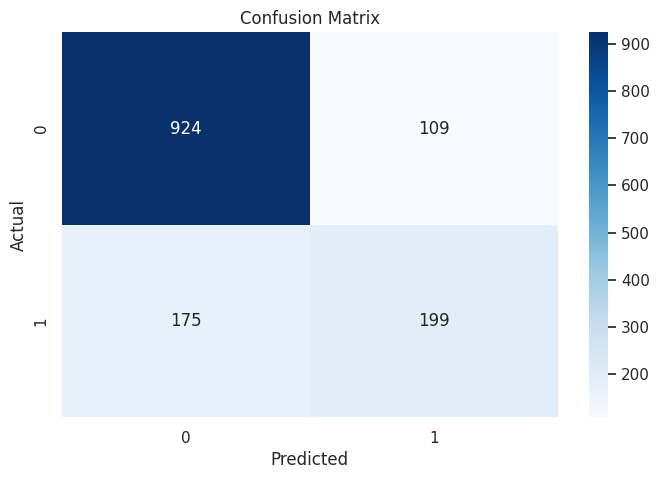

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


### ROC Curve

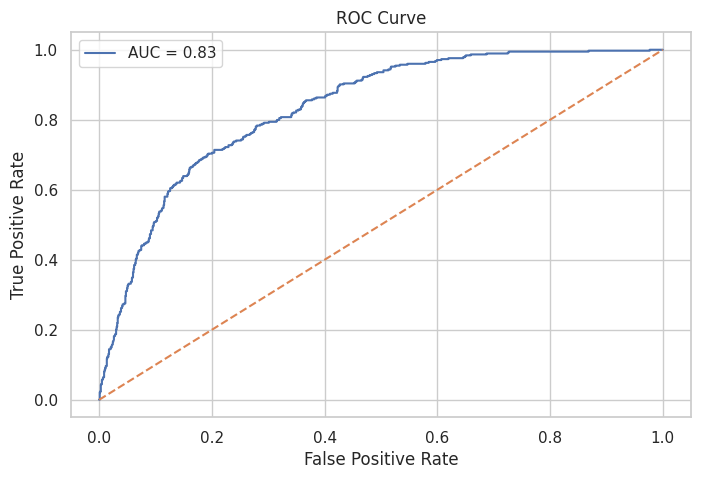

In [ ]:
from sklearn.metrics import roc_curve, auc

# Probability predictions
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,2)))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Saving the baseline for drift analysis

In [ ]:
baseline_probabilities = best_model.predict_proba(X_test)[:,1]

print("Baseline probabilities stored for future drift comparison")

Baseline probabilities stored for future drift comparison


In [ ]:
baseline_probabilities

array([0.03282501, 0.57834102, 0.02012535, ..., 0.11416426, 0.05346951,
       0.01588738])

## Drift Aanalyis

### Creating  Production Data for drift analysis

In [ ]:
# Convert X to DataFrame
X = pd.DataFrame(X, columns=telco.drop("Churn", axis=1).columns)
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

new_data = X_test.copy()
new_data["MonthlyCharges"] = new_data["MonthlyCharges"] * 1.1
new_data["tenure"] = new_data["tenure"] + 0.5
new_data.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
974,0,59.5,83.545,4542.35,False,True,True,True,False,False,...,False,True,False,True,False,True,True,True,False,False
619,0,7.5,86.405,522.95,False,False,False,True,False,True,...,False,False,False,False,False,False,True,False,False,False
4289,0,54.5,22.110,1079.45,False,False,False,True,False,False,...,True,False,True,False,False,True,False,False,False,True
3721,0,2.5,22.715,38.70,False,False,False,True,False,False,...,True,False,True,False,False,False,False,False,False,True
4533,0,71.5,115.665,7555.00,False,True,False,True,False,True,...,False,True,False,True,False,True,True,False,False,False


### PSI (Population Stability Index)

In [ ]:
import numpy as np

def calculate_psi(expected, actual, bins=10):

    # Create bins based on expected data
    breakpoints = np.linspace(0, 100, bins + 1)
    breakpoints = np.percentile(expected, breakpoints)

    # Count values in each bin
    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts = np.histogram(actual, bins=breakpoints)[0]

    # Convert to proportions
    expected_perc = expected_counts / len(expected)
    actual_perc = actual_counts / len(actual)

    # Avoid division by zero
    expected_perc = np.where(expected_perc == 0, 0.0001, expected_perc)
    actual_perc = np.where(actual_perc == 0, 0.0001, actual_perc)

    # PSI calculation
    psi_values = (actual_perc - expected_perc) * np.log(actual_perc / expected_perc)

    return np.sum(psi_values)


### Apply PSI on Features

In [ ]:
# Calculate PSI for selected features
features = ["MonthlyCharges", "tenure"]

for col in features:
    psi_value = calculate_psi(X_test[col], new_data[col])

    if psi_value < 0.1:
        status = "No drift"
    elif psi_value < 0.25:
        status = "Moderate drift"
    else:
        status = "Significant drift"

    print(f"{col} PSI: {round(psi_value, 4)} --> {status}")


MonthlyCharges PSI: 0.7962 --> Significant drift
tenure PSI: 0.022 --> No drift


### KS TEST (Statistical Drift)

In [ ]:
from scipy.stats import ks_2samp

for col in features:
    stat, p_value = ks_2samp(X_test[col], new_data[col])

    if p_value > 0.05:
        status = "No significant drift"
    else:
        status = "Drift detected"

    print(f"{col} KS Statistic: {round(stat,4)}")
    print(f"{col} p-value: {round(p_value,4)} --> {status}")
    print("------")

MonthlyCharges KS Statistic: 0.1628
MonthlyCharges p-value: 0.0 --> Drift detected
------
tenure KS Statistic: 0.0917
tenure p-value: 0.0 --> Drift detected
------


# This for default+of+credit+card+clients.xls

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
credit_default = pd.read_excel("default of credit card clients.xls", header=1)
credit_default.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Data Preprocessing

Feature Engineering and Encoding Rationale

For this dataset, preprocessing separates predictor variables from the default target and prepares them for logistic regression. Numerical features are scaled so that variables measured on different ranges contribute more evenly to optimization. Any categorical or encoded indicator variables are retained in numeric form so the classifier can interpret them consistently.

This approach supports fair comparison of features and helps the model learn patterns related to default risk without being distorted by scale differences.

In [ ]:
# Renaming the target column
credit_default = credit_default.rename( columns={"default payment next month": "default"} )

In [ ]:
# In this dataset data is in numeric
print(credit_default.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   3

In [ ]:
# Splitting feature and target
X = credit_default.drop("default", axis=1)
y = credit_default["default"]

In [ ]:
# Splitting train and test datasets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y )

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (24000, 24)
Test: (6000, 24)


In [ ]:
# Finding feature importance
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

PAY_0        0.093286
ID           0.071426
AGE          0.056722
BILL_AMT1    0.055043
LIMIT_BAL    0.051537
BILL_AMT2    0.049945
PAY_AMT1     0.047794
BILL_AMT3    0.047522
BILL_AMT6    0.046560
BILL_AMT4    0.045993
dtype: float64


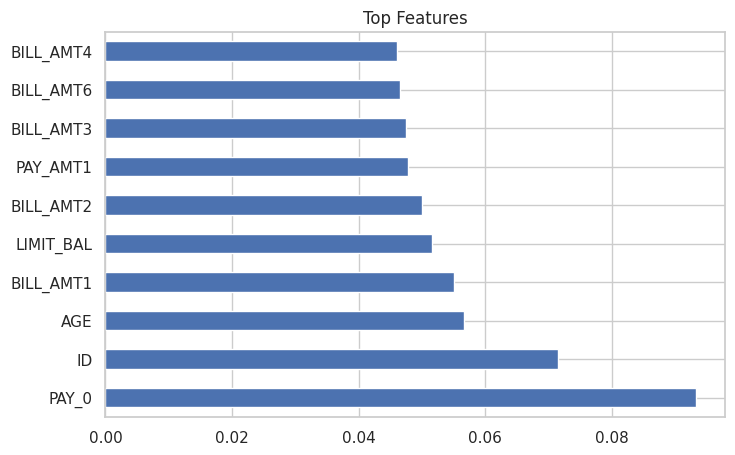

In [ ]:
# Visualizing feature importace
feature_importance.head(10).plot(kind='barh')
plt.title("Top Features")
plt.show()

In [ ]:
# Feature Scaling for best model
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Logistic Regression and Hyperparameter Tuning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [0.01, 0.1, 1, 10]}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5,
    scoring='accuracy')

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)

Best Params: {'C': 0.1}


Hyperparameter Tuning and Validation Rationale

GridSearchCV is used to test multiple values of C under 5-fold cross-validation. This provides a systematic way to select the best model configuration based on performance across several validation folds rather than relying on a single split. The goal is to produce a model that generalizes well to new cases and avoids overfitting.

In [ ]:
# Best model parameters
best_model = grid_search.best_estimator_
best_model

LogisticRegression(C=0.1, max_iter=5000)

In [ ]:
# Prediction and evaluation of model
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.808
Precision: 0.6889848812095032
Recall: 0.24039186134137153


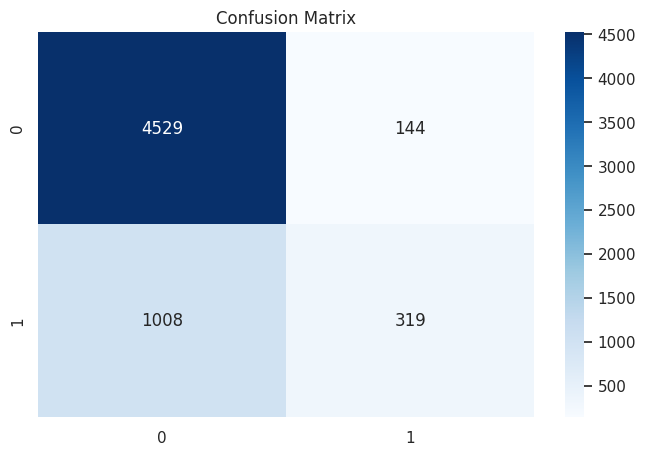

In [ ]:
# Confusion matrix heatmap
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

Classification Metrics Interpretation

The confusion matrix and classification metrics provide more insight than accuracy alone. Precision reflects how trustworthy positive default predictions are, while recall reflects how well the model captures actual defaults. In financial prediction tasks, false negatives can be especially risky because missed default cases may lead to financial loss, while false positives may lead to unnecessary caution or review. The preferred balance depends on the organization's risk tolerance.

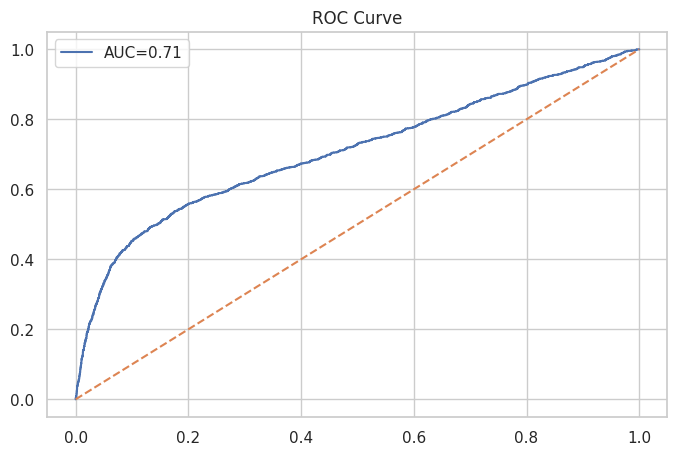

In [ ]:
# ROC curve chart
from sklearn.metrics import roc_curve, auc
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC=" + str(round(roc_auc,2)))
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

In [ ]:
# Savig baseline probabilites for later drift
baseline_probabilities = y_prob
baseline_probabilities

array([0.11028307, 0.11619765, 0.2187376 , ..., 0.15503383, 0.11772683,
       0.04280398])

### Drift Analysis on this dataset

In [ ]:
# Converting back to dataFrame
X = pd.DataFrame(X, columns=credit_default.drop("default", axis=1).columns)

# Split the X dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create new data for drifting
new_data = X_test.copy()

new_data["LIMIT_BAL"] = new_data["LIMIT_BAL"] * 1.2
new_data["AGE"] = new_data["AGE"] + 2
new_data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
6907,6908,60000.0,1,2,2,48,-1,-1,-1,-1,...,0,2650,3320,2764,26060,0,3472,2320,1764,2841
24575,24576,180000.0,1,1,1,33,-1,-1,-2,-2,...,0,0,0,11694,0,0,0,0,11694,30000
26766,26767,60000.0,1,2,2,27,0,0,0,0,...,49009,49949,50479,50702,1800,1844,2200,2000,1800,2038
2156,2157,348000.0,2,1,2,27,0,0,0,0,...,296384,248801,241983,230925,15000,10500,10000,15000,7844,23333
3179,3180,600000.0,2,2,1,29,-2,-2,-2,-2,...,13570,10000,10000,10000,9983,13587,10000,10000,10000,25304


In [ ]:
# PSI calculation
import numpy as np

def calculate_psi(expected, actual, bins=10):

    breakpoints = np.linspace(0, 100, bins + 1)
    breakpoints = np.percentile(expected, breakpoints)

    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts = np.histogram(actual, bins=breakpoints)[0]

    expected_perc = expected_counts / len(expected)
    actual_perc = actual_counts / len(actual)

    expected_perc = np.where(expected_perc == 0, 0.0001, expected_perc)
    actual_perc = np.where(actual_perc == 0, 0.0001, actual_perc)

    psi = (actual_perc - expected_perc) * np.log(actual_perc / expected_perc)

    return np.sum(psi)

In [ ]:
# Applying  PSI for specific features
features = ["LIMIT_BAL", "AGE"]

for col in features:
    psi_value = calculate_psi(X_test[col], new_data[col])

    if psi_value < 0.1:
        status = "No drift"
    elif psi_value < 0.25:
        status = "Moderate drift"
    else:
        status = "Significant drift"

    print(f"{col} PSI: {round(psi_value,4)} --> {status}")

LIMIT_BAL PSI: 0.051 --> No drift
AGE PSI: 0.1336 --> Moderate drift


In [ ]:
# Applyig KS test
from scipy.stats import ks_2samp

for col in features:
    stat, p_value = ks_2samp(X_test[col], new_data[col])

    if p_value > 0.05:
        status = "No significant drift"
    else:
        status = "Drift detected"

    print(f"{col} KS Statistic:", round(stat,4))
    print(f"{col} p-value:", round(p_value,4), "-->", status)
    print("------")

LIMIT_BAL KS Statistic: 0.1113
LIMIT_BAL p-value: 0.0 --> Drift detected
------
AGE KS Statistic: 0.1008
AGE p-value: 0.0 --> Drift detected
------


# This is for German dataset

In [ ]:
# Loading German credit dataset with no heading and seprated with spaces
german_credit = pd.read_csv("german.data", sep=' ', header=None)
german_credit.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [ ]:
# Give column names to the dataset
columns = [
    "Status", "Duration", "CreditHistory", "Purpose", "CreditAmount",
    "Savings", "Employment", "InstallmentRate", "PersonalStatus",
    "OtherDebtors", "ResidenceDuration", "Property", "Age",
    "OtherInstallmentPlans", "Housing", "ExistingCredits",
    "Job", "LiablePeople", "Telephone", "ForeignWorker", "Target"
]
german_credit.columns = columns
german_credit.head()

,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,Employment,InstallmentRate,PersonalStatus,OtherDebtors,...,Property,Age,OtherInstallmentPlans,Housing,ExistingCredits,Job,LiablePeople,Telephone,ForeignWorker,Target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [ ]:
# Remove spaces and convert to integer the target column
german_credit["Target"] = german_credit["Target"].astype(str).str.strip().astype(int)

### Data Preprocessing

Feature Engineering and Preprocessing Rationale

The German credit dataset includes a mix of numeric and encoded categorical information. Preprocessing prepares the data so that all variables can be used consistently by logistic regression. Scaling is applied where appropriate to improve optimization and keep features on comparable ranges. This helps the model evaluate credit-related factors without overweighting variables that simply have larger numeric magnitudes.

In [ ]:
# Convert target column to 0 and 1
german_credit["Target"] = german_credit["Target"].map({1: 0, 2: 1})
german_credit

,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,Employment,InstallmentRate,PersonalStatus,OtherDebtors,...,Property,Age,OtherInstallmentPlans,Housing,ExistingCredits,Job,LiablePeople,Telephone,ForeignWorker,Target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,0
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,0
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,0
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,1


In [ ]:
# Converting categorical columns into numeric values using one-hot encoding
german_credit = pd.get_dummies(german_credit, drop_first=True)
german_credit.head()

,Duration,CreditAmount,InstallmentRate,ResidenceDuration,Age,ExistingCredits,LiablePeople,Target,Status_A12,Status_A13,...,Property_A124,OtherInstallmentPlans_A142,OtherInstallmentPlans_A143,Housing_A152,Housing_A153,Job_A172,Job_A173,Job_A174,Telephone_A192,ForeignWorker_A202
0,6,1169,4,4,67,2,1,0,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,1,True,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,0,False,False,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,0,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,1,False,False,...,True,False,True,False,True,False,True,False,False,False


In [ ]:
# Splitting feature columns and target
X = german_credit.drop("Target", axis=1)
y = german_credit["Target"]

In [ ]:
# Splitting the dataset into test and train
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (800, 48)
Testing shape: (200, 48)


In [ ]:
# Finding feature importance
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top Features:\n", feature_importance.head(10))

Top Features:
 CreditAmount                  0.111172
Age                           0.091510
Duration                      0.089528
Status_A14                    0.066055
InstallmentRate               0.042282
ResidenceDuration             0.034296
OtherInstallmentPlans_A143    0.024549
CreditHistory_A34             0.024025
Status_A12                    0.023706
Savings_A65                   0.021822
dtype: float64


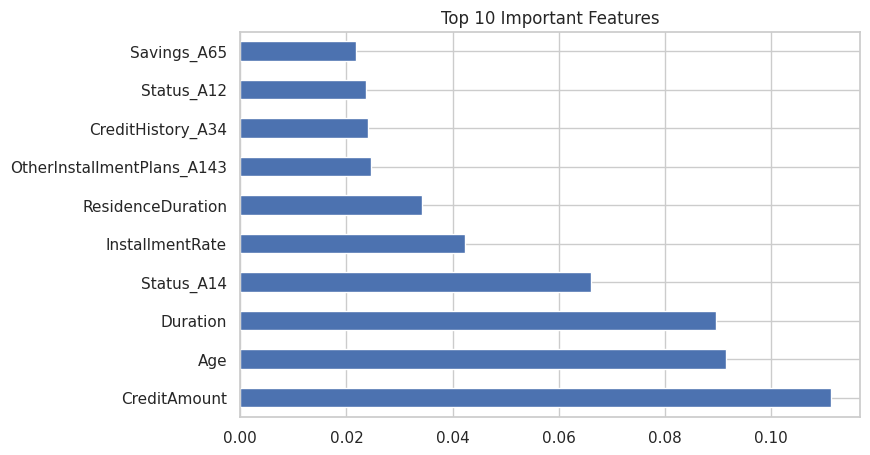

In [ ]:
# Visualizing feature importance
feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

In [ ]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Apply Logistic Regression with Hyperparameter Tuning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 0.1}


Hyperparameter Tuning and Generalization

The model is tuned by searching across multiple C values and evaluating each option with cross-validation. This allows the notebook to justify why the selected model is preferred rather than choosing parameters arbitrarily. A tuned model is more likely to maintain performance on unseen applicants and demonstrate robustness.

In [ ]:
# Find the best model parameters
best_model = grid_search.best_estimator_
best_model

LogisticRegression(C=0.1, max_iter=5000)

In [ ]:
# Predicting and calculating evaluation of model
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.785
Precision: 0.6808510638297872
Recall: 0.5333333333333333


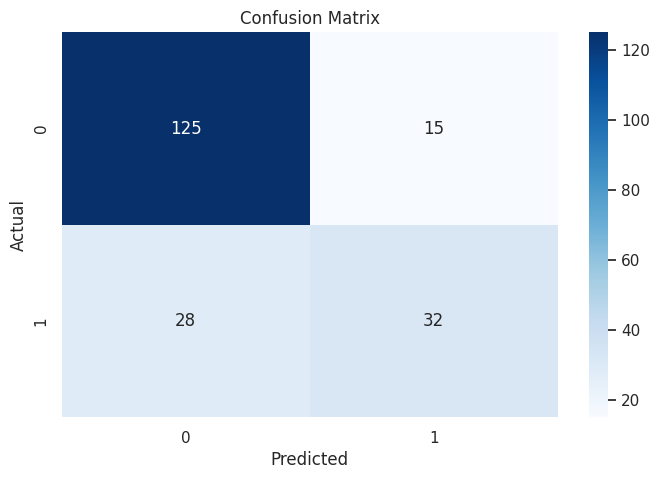

In [ ]:
#  Print confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Evaluation Interpretation and False Positive/False Negative Tradeoff

For credit prediction, the confusion matrix highlights two important error types. A false positive occurs when the model predicts a poor credit outcome for someone who is actually good, which may unfairly restrict approval. A false negative occurs when the model predicts a good outcome for someone who is actually risky, which may expose the lender to loss. Because these errors have different business consequences, precision and recall should be interpreted together rather than relying only on accuracy.

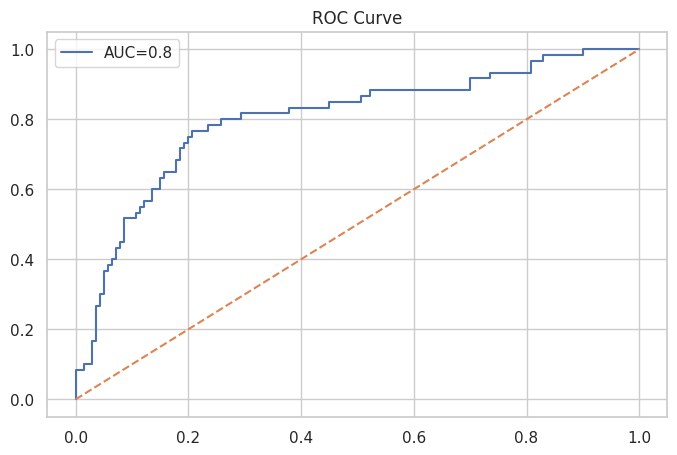

In [ ]:
# Pring ROC Curve
from sklearn.metrics import roc_curve, auc

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC=" + str(round(roc_auc,2)))
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

### Drift Analysis

In [ ]:
# Creating Drift data
# Convert X back to dataframe
X = pd.DataFrame(X, columns=german_credit.drop("Target", axis=1).columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

new_data = X_test.copy()

new_data["CreditAmount"] = new_data["CreditAmount"] * 1.2
new_data["Age"] = new_data["Age"] + 3
new_data.head()

,Duration,CreditAmount,InstallmentRate,ResidenceDuration,Age,ExistingCredits,LiablePeople,Status_A12,Status_A13,Status_A14,...,Property_A124,OtherInstallmentPlans_A142,OtherInstallmentPlans_A143,Housing_A152,Housing_A153,Job_A172,Job_A173,Job_A174,Telephone_A192,ForeignWorker_A202
30,18,2295.6,3,3,39,1,1,True,False,False,...,False,False,False,True,False,False,True,False,True,False
128,12,2232.0,4,2,37,2,1,True,False,False,...,False,False,True,True,False,False,False,True,True,False
289,24,1228.8,4,4,51,1,1,False,False,False,...,False,True,False,True,False,False,True,False,False,False
216,18,3724.8,3,1,34,1,1,False,False,False,...,False,False,False,True,False,False,True,False,True,False
966,27,3024.0,4,2,26,2,1,True,False,False,...,False,False,True,True,False,True,False,False,False,False


In [ ]:
# PSI function
import numpy as np

def calculate_psi(expected, actual, bins=10):
    breakpoints = np.linspace(0, 100, bins + 1)
    breakpoints = np.percentile(expected, breakpoints)

    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts = np.histogram(actual, bins=breakpoints)[0]

    expected_perc = expected_counts / len(expected)
    actual_perc = actual_counts / len(actual)

    expected_perc = np.where(expected_perc == 0, 0.0001, expected_perc)
    actual_perc = np.where(actual_perc == 0, 0.0001, actual_perc)

    psi = (actual_perc - expected_perc) * np.log(actual_perc / expected_perc)
    return np.sum(psi)

In [ ]:
# Applying PSI on old and new data for specific columns
features = ["CreditAmount", "Age"]

for col in features:
    psi_value = calculate_psi(X_test[col], new_data[col])

    if psi_value < 0.1:
        status = "No drift"
    elif psi_value < 0.25:
        status = "Moderate drift"
    else:
        status = "Significant drift"

    print(f"{col} PSI: {round(psi_value,4)} --> {status}")

CreditAmount PSI: 0.1053 --> Moderate drift
Age PSI: 0.5512 --> Significant drift


In [ ]:
#  Applying KS Test on old and new data
from scipy.stats import ks_2samp

for col in features:
    stat, p_value = ks_2samp(X_test[col], new_data[col])

    if p_value > 0.05:
        status = "No significant drift"
    else:
        status = "Drift detected"

    print(f"{col} KS Statistic:", round(stat,4))
    print(f"{col} p-value:", round(p_value,4), "-->", status)
    print("------")

CreditAmount KS Statistic: 0.115
CreditAmount p-value: 0.1421 --> No significant drift
------
Age KS Statistic: 0.17
Age p-value: 0.0061 --> Drift detected
------
